## Setup and Imports
This section imports all required libraries for data analysis, loads the dataset into a DataFrame, and defines a utility function that logs completed tasks to a separate .txt file for documentation and reproducibility.

In [337]:
#Import libraries
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [338]:
# Function to record tasks into Travel_Log.txt
from datetime import datetime, timezone

def tlog(task_completed, why, tools_used="", notes="", file="travel_log.txt"):
    ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

    entry = (
        f"[{ts}]\n"
        f"Task completed: {task_completed}\n"
        f"Why I did it: {why}\n"
        f"Tools/commands used (optional): {tools_used}\n"
        f"Notes: {notes}\n\n")
    with open(file, "a", encoding="utf-8") as f:
        f.write(entry)

#Example of cell log to record each task:
#tlog(
    #task_completed="text", 
    #why="text", 
    #tools_used="text", 
    #notes="text") 

In [339]:
# Import and read Supermarket data
supermarket = pd.read_csv("SupermarketEvaluation.csv")

## Preliminary Data Examination
This includes data familiarization and descriptive stats to understand each field: 
Range, mean, median, SD.
- Records and # fields (attributes) 
- Proportion of fields with missing values

In [340]:
supermarket.sample(10) #Random sample to inspect data

,age,household_income,gender,store_location,typical_queue_wait_time,distance_to_store,percent_self_service_checkout_uses,children,fruit_and_veg_items,meat_items,...,other_items,has_loyalty_card,brand_loyalty,typical_visit_time,typical_shopping_mission,brings_own_bag,average_time_in_store,typical_payment_method,satisfaction,Customer_Comment
4218,61,44999.0,Male,Wymondham,17.3,2.4,0.00,0,8,5,...,3,No,High,Morning,Weekly shop,Yes,87.8,Card,Very Low,NaN
1059,53,73694.0,Female,Norwich,14.9,8.1,0.02,1,10,1,...,4,No,Medium,Evening,Top-up,Yes,50.1,Card,Very Low,NaN
3525,31,NaN,Non-binary,Norwich,16.5,NaN,0.17,2,8,7,...,1,No,Medium,Afternoon,Weekly shop,Yes,67.0,Card,Low,Not the best visit on my way home doing a bigg...
2961,52,107765.0,Female,Thetford,8.7,3.1,0.14,1,8,2,...,4,No,Medium,Morning,Top-up,Yes,52.2,Card,Low,NaN
4234,51,53405.0,Female,Norwich,6.3,0.7,0.52,0,9,3,...,7,Yes,Low,Afternoon,Weekly shop,No,40.5,Unknown,High,A good experience overall after work doing a q...
4451,70,62451.0,Non-binary,Wymondham,17.0,5.6,0.00,1,13,1,...,4,No,High,Evening,Top-up,No,89.2,Card,Very Low,NaN
4429,42,45771.0,Male,Thetford,18.4,1.4,0.09,2,10,2,...,7,No,Medium,Morning,Top-up,Yes,64.3,Apple Pay,Very Low,NaN
4665,20,NaN,Non-binary,Wymondham,8.3,3.8,0.61,0,6,2,...,1,Yes,Medium,Evening,Weekly shop,Yes,49.4,Cash,Medium,Neither great nor terrible today doing a bigge...
2433,54,32908.0,Male,Wymondham,14.5,NaN,0.05,1,9,2,...,5,No,Medium,Evening,Weekly shop,Yes,86.2,Card,Very Low,NaN
2022,34,50949.0,Male,Fakenham,17.9,1.3,0.19,0,7,1,...,3,No,Low,Afternoon,Top-up,Yes,42.0,Unknown,Very Low,Not acceptable today this afternoon doing a bi...


In [341]:
supermarket.info() #Basic information including data types and NaNs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   age                                 5000 non-null   int64  
 1   household_income                    4812 non-null   float64
 2   gender                              4919 non-null   object 
 3   store_location                      5000 non-null   object 
 4   typical_queue_wait_time             4952 non-null   float64
 5   distance_to_store                   4088 non-null   float64
 6   percent_self_service_checkout_uses  5000 non-null   float64
 7   children                            5000 non-null   int64  
 8   fruit_and_veg_items                 5000 non-null   int64  
 9   meat_items                          5000 non-null   int64  
 10  cupboard_items                      5000 non-null   int64  
 11  frozen_items                        4905 no

In [342]:
supermarket.describe() #Summary stats

,age,household_income,typical_queue_wait_time,distance_to_store,percent_self_service_checkout_uses,children,fruit_and_veg_items,meat_items,cupboard_items,frozen_items,toiletries_items,other_items,average_time_in_store
count,5000.000000,4.812000e+03,4952.000000,4088.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4905.000000,4941.000000,5000.000000,5000.000000
mean,48.790800,6.474890e+04,41.797920,1.954232,0.331838,0.756400,7.749800,4.123200,6.774400,3.974924,2.364906,3.079800,66.233060
std,33.874901,3.969892e+05,466.637391,1.330235,0.250311,0.924137,4.306984,3.682001,6.124198,3.732761,2.780538,2.034075,18.235361
min,20.000000,5.081000e+03,2.200000,0.300000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000
25%,31.000000,2.546500e+04,9.600000,1.100000,0.100000,0.000000,5.000000,1.000000,2.000000,1.000000,0.000000,2.000000,53.000000
50%,46.000000,3.595550e+04,12.000000,1.600000,0.300000,0.000000,7.000000,3.000000,5.000000,3.000000,1.000000,3.000000,63.700000
75%,60.000000,5.202925e+04,14.500000,2.300000,0.530000,1.000000,10.000000,6.000000,9.000000,6.000000,3.000000,4.000000,76.600000
max,367.000000,1.003282e+07,9920.400000,16.500000,0.970000,3.000000,39.000000,27.000000,54.000000,27.000000,20.000000,20.000000,184.300000


In [343]:
supermarket.shape #Check for number of rows/columns

(5000, 23)

In [344]:
supermarket[supermarket.duplicated()] #Check for duplicate rows

,age,household_income,gender,store_location,typical_queue_wait_time,distance_to_store,percent_self_service_checkout_uses,children,fruit_and_veg_items,meat_items,...,other_items,has_loyalty_card,brand_loyalty,typical_visit_time,typical_shopping_mission,brings_own_bag,average_time_in_store,typical_payment_method,satisfaction,Customer_Comment


In [345]:
print(supermarket.isnull().sum()) #Check for missing values
print(supermarket.isnull().sum() * 100 / len(supermarket)) #Percentage

age                                      0
household_income                       188
gender                                  81
store_location                           0
typical_queue_wait_time                 48
distance_to_store                      912
percent_self_service_checkout_uses       0
children                                 0
fruit_and_veg_items                      0
meat_items                               0
cupboard_items                           0
frozen_items                            95
toiletries_items                        59
other_items                              0
has_loyalty_card                         0
brand_loyalty                            0
typical_visit_time                       0
typical_shopping_mission                 0
brings_own_bag                           0
average_time_in_store                    0
typical_payment_method                 199
satisfaction                             0
Customer_Comment                      1577
dtype: int6

In [346]:
supermarket.nunique() #Check unique values in each column

age                                    109
household_income                      4661
gender                                   5
store_location                         162
typical_queue_wait_time                258
distance_to_store                       91
percent_self_service_checkout_uses      98
children                                 4
fruit_and_veg_items                     31
meat_items                              27
cupboard_items                          41
frozen_items                            27
toiletries_items                        21
other_items                             18
has_loyalty_card                         2
brand_loyalty                            3
typical_visit_time                       3
typical_shopping_mission                40
brings_own_bag                           2
average_time_in_store                  835
typical_payment_method                  17
satisfaction                             5
Customer_Comment                      3423
dtype: int6

In [347]:
print(supermarket.shape) #Check value counts
supermarket['gender'].value_counts()

(5000, 23)


gender
Female               2192
Male                 2185
Non-binary            231
Prefer not to say     206
Other                 105
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

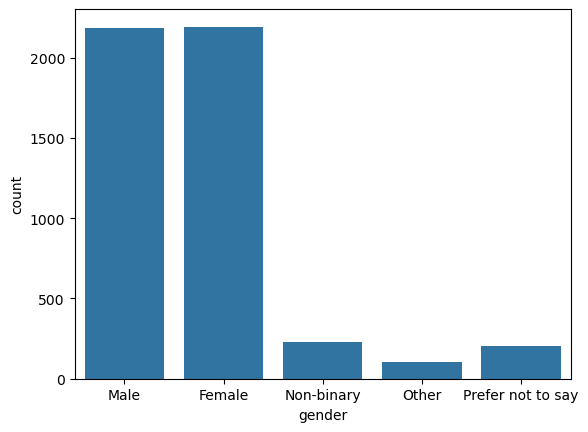

In [348]:
sns.countplot(x='gender' , data = supermarket) #Countplot of gender (Figure 1)

In [349]:
supermarket['age'].describe() #Retrieving age stats

count    5000.000000
mean       48.790800
std        33.874901
min        20.000000
25%        31.000000
50%        46.000000
75%        60.000000
max       367.000000
Name: age, dtype: float64

In [350]:
supermarket['age'].median() #Median age

46.0

In [351]:
supermarket['household_income'].describe()

count    4.812000e+03
mean     6.474890e+04
std      3.969892e+05
min      5.081000e+03
25%      2.546500e+04
50%      3.595550e+04
75%      5.202925e+04
max      1.003282e+07
Name: household_income, dtype: float64

In [352]:
#Check for unreasonable ages
age_outliers = supermarket[(supermarket['age'] < 18) | (supermarket['age'] > 120)]
age_outliers.head()['age']

34     283
39     325
41     332
92     335
161    225
Name: age, dtype: int64

In [353]:
#Find income outliers using IQR method (Copilot generated)
Q1 = supermarket['household_income'].quantile(0.25)
Q3 = supermarket['household_income'].quantile(0.75)
IQR = Q3 - Q1
income_outliers = supermarket[(supermarket['household_income'] < (Q1 - 1.5 * IQR)) |
                     (supermarket['household_income'] > (Q3 + 1.5 * IQR))]

income_outliers.head()['household_income']

9        94444.0
46      150327.0
53    10032823.0
64      129262.0
74      131325.0
Name: household_income, dtype: float64

In [354]:
# Extracting categorical and numerical features (Retrieved from Youtube video)
# https://youtu.be/lXcBYSN67ig?si=dKNIHP_y_cEfEeS7
categorical_features = supermarket.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = supermarket.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['gender', 'store_location', 'has_loyalty_card', 'brand_loyalty', 'typical_visit_time', 'typical_shopping_mission', 'brings_own_bag', 'typical_payment_method', 'satisfaction', 'Customer_Comment']
Numerical Features: ['age', 'household_income', 'typical_queue_wait_time', 'distance_to_store', 'percent_self_service_checkout_uses', 'children', 'fruit_and_veg_items', 'meat_items', 'cupboard_items', 'frozen_items', 'toiletries_items', 'other_items', 'average_time_in_store']


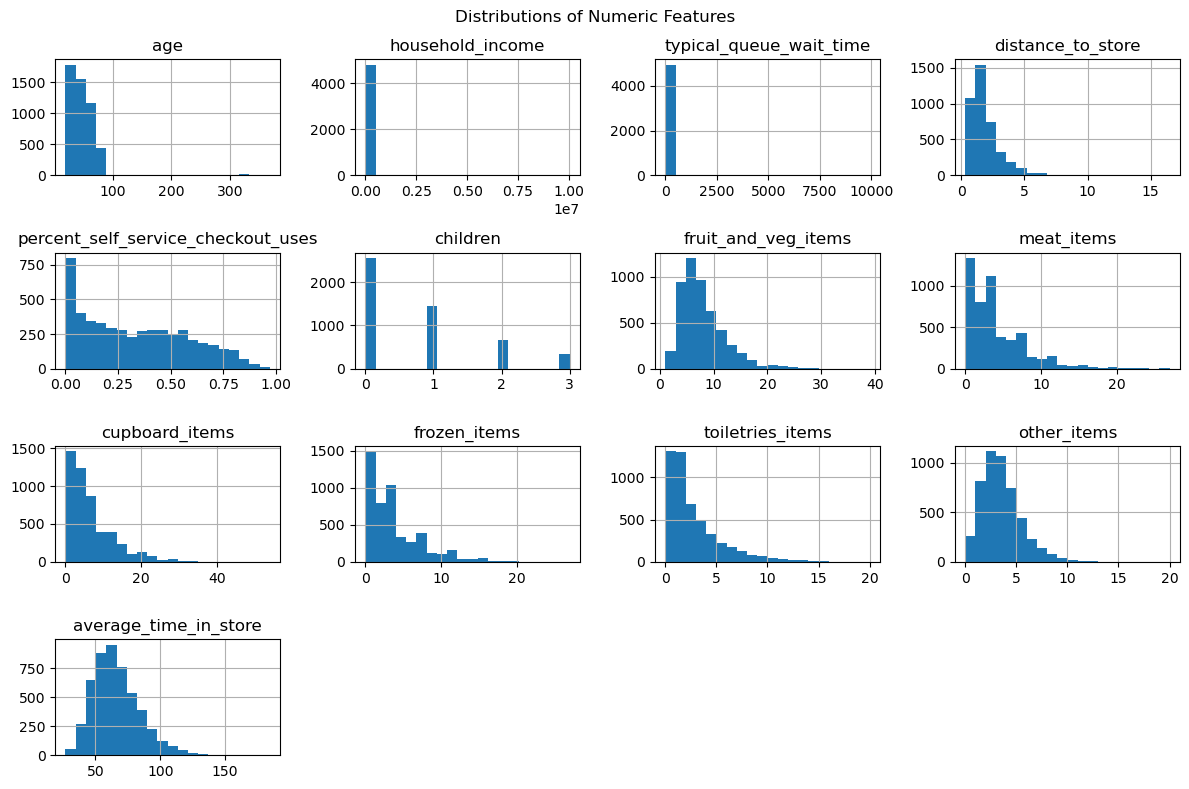

In [355]:
# Histograms of numerical features
#(Retrieved from Youtube video) (Figure 2)
# https://youtu.be/lXcBYSN67ig?si=dKNIHP_y_cEfEeS7
supermarket[numerical_features].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()

## Data Cleansing
Preparing and transforming data for later learning stages by improving quality.

**Key Activities:**
- String cleaning
- Manage NaNs and missing data
- Handle outliers
- Balance target variables and data types

### String Cleaning 
Ensure that all manually entered text values are accurately spelled to support reliable data analysis.

In [356]:
#Removing columns that are not useful (New dataframe variable)
df = supermarket.drop(columns=["brings_own_bag", "brand_loyalty"])

In [357]:
#Use of fuzzy matching to ensure correct city spelling (Copilot generated)
##Imports a library that finds closest matching strings
from difflib import get_close_matches
#Correct city spelling into variable
valid_cities = ["Wymondham", "Fakenham", "Dereham", "Norwich", "Thetford"]

#Function to look for the closest match (must be at least 75% similar)
def fix_city(x): 
    match = get_close_matches(str(x), valid_cities, n=1, cutoff=0.75)
    return match[0] if match else x

df['store_location'] = df['store_location'].apply(fix_city)
df['store_location'].value_counts() #Check for misspellings

store_location
Wymondham    1058
Fakenham     1031
Norwich      1025
Dereham      1010
Thetford      876
Name: count, dtype: int64

In [358]:
df['typical_payment_method'].unique() #Shows all unique values for typical payment method

array(['Cash', nan, 'Google Pay', 'Card', 'Apple Pay', 'Unknown', 'Cad',
       'Cajrd', 'Cas', 'ard', 'Crd', 'Cakrd', 'Crard', 'Casth', 'Cardf',
       'Caard', 'Google Payn', 'wCard'], dtype=object)

In [359]:
# Fix common typos (Manual fix since there are not a lot of incorrect values)
df['typical_payment_method'] = (
    df['typical_payment_method']
        .astype("string") # make everything a string
        .str.strip()      # remove spaces before/after text
        .replace({
            "Cad": "Card",
            "Cajrd": "Card",
            "Cas": "Cash",
            "Casth": "Cash",
            "ard": "Card",
            "Crd": "Card",
            "Cakrd": "Card",
            "Crard": "Card",
            "Cardf": "Card",
            "Caard": "Card",
            "wCard": "Card",
            "Google Payn": "Google Pay"}))

df['typical_payment_method'].value_counts()

typical_payment_method
Card          2738
Cash          1018
Apple Pay      586
Google Pay     263
Unknown        196
Name: count, dtype: Int64

In [360]:
#Use of fuzzy matching to ensure correct mission spelling
#Correct city spelling into variable
valid_missions = ["Weekly shop", "Top-up", "Bulk shop"]

#Function to look for the closest match (must be at least 75% similar)
def fix_mission(x):
    match = get_close_matches(str(x), valid_missions, n=1, cutoff=0.75)
    return match[0] if match else x

df['typical_shopping_mission'] = df['typical_shopping_mission'].apply(fix_mission)
df['typical_shopping_mission'].value_counts() #Check for misspellings

typical_shopping_mission
Top-up         2085
Weekly shop    2068
Bulk shop       847
Name: count, dtype: int64

### NaNs/Null Values
Imputing missing values.

In [361]:
print(df['Customer_Comment'].isna().sum()) #Check for count of NaNs
print(df['Customer_Comment'].notna().sum()) #Check for count of inputs

1577
3423


In [362]:
#Fill in NaNs for Customer Comment (useful when preparing text data)
df['Customer_Comment'] = df['Customer_Comment'].fillna('')
df['Customer_Comment'].isna().sum()

np.int64(0)

In [363]:
#Fill in blanks with Unknown
df['typical_payment_method'] = df['typical_payment_method'].fillna('Unknown') 
df['gender'] = df['gender'].fillna('Unknown')

In [364]:
#List of numeric columns to replace NaNs in each column with median
num_cols = ['household_income', 'typical_queue_wait_time',
            'distance_to_store', 'frozen_items', 'toiletries_items']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.isnull().sum()

age                                   0
household_income                      0
gender                                0
store_location                        0
typical_queue_wait_time               0
distance_to_store                     0
percent_self_service_checkout_uses    0
children                              0
fruit_and_veg_items                   0
meat_items                            0
cupboard_items                        0
frozen_items                          0
toiletries_items                      0
other_items                           0
has_loyalty_card                      0
typical_visit_time                    0
typical_shopping_mission              0
average_time_in_store                 0
typical_payment_method                0
satisfaction                          0
Customer_Comment                      0
dtype: int64

### Removing Outliers
Remove outliers to improve quality of data analysis.

In [365]:
lower, upper = 18, 120 #Setting age parameter

df['age'] = supermarket['age'].clip(lower=lower, upper=upper)
df['age'].describe()

count    5000.000000
mean       46.431000
std        19.354869
min        20.000000
25%        31.000000
50%        46.000000
75%        60.000000
max       120.000000
Name: age, dtype: float64

In [366]:
lower = Q1 - 1.5 * IQR #Setting income parameter
upper = Q3 + 1.5 * IQR

df['household_income'] = df['household_income'].clip(lower=lower, upper=upper)
df['household_income'].describe()

count     5000.000000
mean     40804.798050
std      20741.169082
min       5081.000000
25%      25870.000000
50%      35955.500000
75%      51354.000000
max      91875.625000
Name: household_income, dtype: float64

In [367]:
#Checking for unreasonable queue wait time values
#Checks sum of values that are greater than 1200 seconds (20 min.)
#Checks sum of values that are greater than 1800 seconds (30 min.)
print((df['typical_queue_wait_time'] > 1200).sum()) 
print((df['typical_queue_wait_time'] > 1800).sum()) 

23
22


In [368]:
#Setting queue wait time parameter
df = df[df['typical_queue_wait_time'] <= 1800] 
df['typical_queue_wait_time'].describe()

count    4978.000000
mean       12.557995
std        23.861344
min         2.200000
25%         9.600000
50%        12.000000
75%        14.400000
max      1674.100000
Name: typical_queue_wait_time, dtype: float64

In [369]:
df['average_time_in_store'].describe() #Check time in store

count    4978.000000
mean       66.254158
std        18.240746
min        27.000000
25%        53.025000
50%        63.700000
75%        76.600000
max       184.300000
Name: average_time_in_store, dtype: float64

In [370]:
#Check for unreasonable outliers of numercial features
df[['age', 'household_income', 'typical_queue_wait_time', 'distance_to_store', 
    'percent_self_service_checkout_uses','children', 'fruit_and_veg_items', 
    'meat_items', 'cupboard_items', 'frozen_items', 
    'toiletries_items', 'other_items', 'average_time_in_store']].describe() 

,age,household_income,typical_queue_wait_time,distance_to_store,percent_self_service_checkout_uses,children,fruit_and_veg_items,meat_items,cupboard_items,frozen_items,toiletries_items,other_items,average_time_in_store
count,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000,4978.000000
mean,46.429490,40830.237369,12.557995,1.890900,0.331754,0.755725,7.747690,4.122338,6.779229,3.959823,2.349538,3.078144,66.254158
std,19.374443,20744.700200,23.861344,1.211909,0.250485,0.923534,4.304399,3.677050,6.125969,3.701651,2.769339,2.034690,18.240746
min,20.000000,5081.000000,2.200000,0.300000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000
25%,31.000000,25891.750000,9.600000,1.200000,0.100000,0.000000,5.000000,1.000000,2.000000,1.000000,0.000000,2.000000,53.025000
50%,46.000000,35955.500000,12.000000,1.600000,0.300000,0.000000,7.000000,3.000000,5.000000,3.000000,1.000000,3.000000,63.700000
75%,60.000000,51372.500000,14.400000,2.100000,0.530000,1.000000,10.000000,6.000000,9.000000,5.000000,3.000000,4.000000,76.600000
max,120.000000,91875.625000,1674.100000,16.500000,0.970000,3.000000,39.000000,27.000000,54.000000,27.000000,20.000000,20.000000,184.300000


### Data Types
In this section, column data types can be changed to improve performance, clarity, and consistency.

In [371]:
#Changed data type to integer
df = df.astype({'frozen_items':'int','toiletries_items':'int'})

In [372]:
#Changed data type to category and bool
df = df.astype({
    'typical_payment_method':'category',
    'gender':'category','store_location':'category',
    'typical_shopping_mission':'category'})

In [373]:
#Changed data type to ordered categories
df['satisfaction'] = df['satisfaction'].astype(
    pd.CategoricalDtype(['Very Low', 'Low', 'Medium', 'High', 'Very High'], ordered=True))

df['typical_visit_time'] = df['typical_visit_time'].astype(
    pd.CategoricalDtype(['Morning','Afternoon','Evening'], ordered=True))

df.dtypes

age                                      int64
household_income                       float64
gender                                category
store_location                        category
typical_queue_wait_time                float64
distance_to_store                      float64
percent_self_service_checkout_uses     float64
children                                 int64
fruit_and_veg_items                      int64
meat_items                               int64
cupboard_items                           int64
frozen_items                             int64
toiletries_items                         int64
other_items                              int64
has_loyalty_card                        object
typical_visit_time                    category
typical_shopping_mission              category
average_time_in_store                  float64
typical_payment_method                category
satisfaction                          category
Customer_Comment                        object
dtype: object

## Exploratory Visualisations
Post‑transformation visualisations that clearly explain the data and its suitability for a learning task.

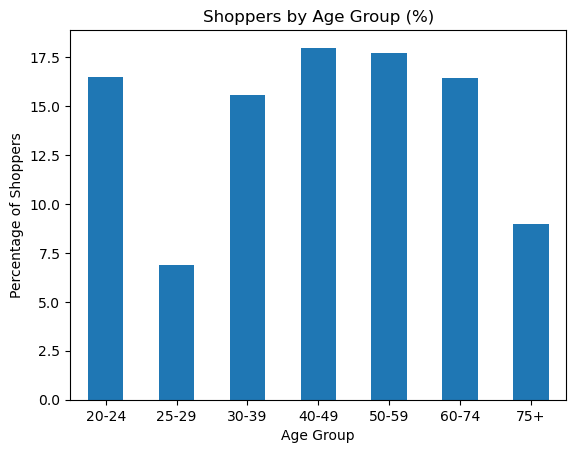

bins: [20, 25, 30, 40, 50, 60, 75, inf]
labels: ['20-24', '25-29', '30-39', '40-49', '50-59', '60-74', '75+']


age
20-24    16.472479
25-29     6.890317
30-39    15.548413
40-49    17.979108
50-59    17.717959
60-74    16.412214
75+       8.979510
Name: proportion, dtype: float64

In [374]:
# Bar chart of percentage of how many shoppers in each group in age_pct variable (Figure 3)
age_pct = (
    pd.cut(df['age'], bins=bins, labels=labels, ordered=True, right=False)
    .value_counts(normalize=True)
    .sort_index()
    * 100)

plt.figure()
age_pct.plot(kind='bar')
plt.title('Shoppers by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Shoppers')
plt.xticks(rotation=0)
plt.show()
print("bins:", bins)
print("labels:", labels)
age_pct

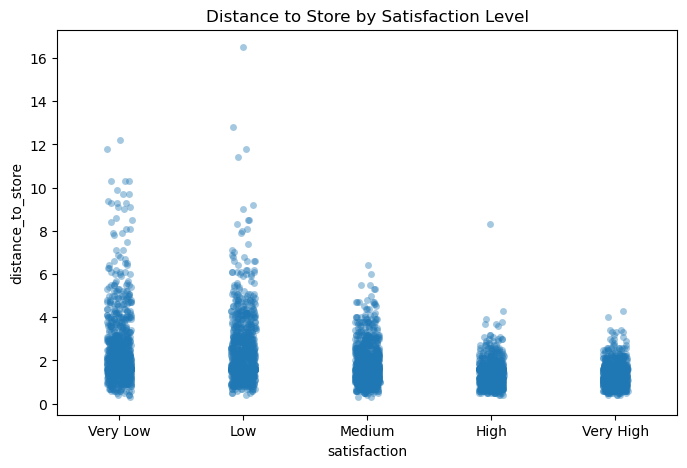

In [375]:
#Strip plot of distance to store vs Satisfaction (Figure 4)
plt.figure(figsize=(8,5))
sns.stripplot(data=df, x="satisfaction", y="distance_to_store", alpha=0.4)
plt.title("Distance to Store by Satisfaction Level")
plt.show()

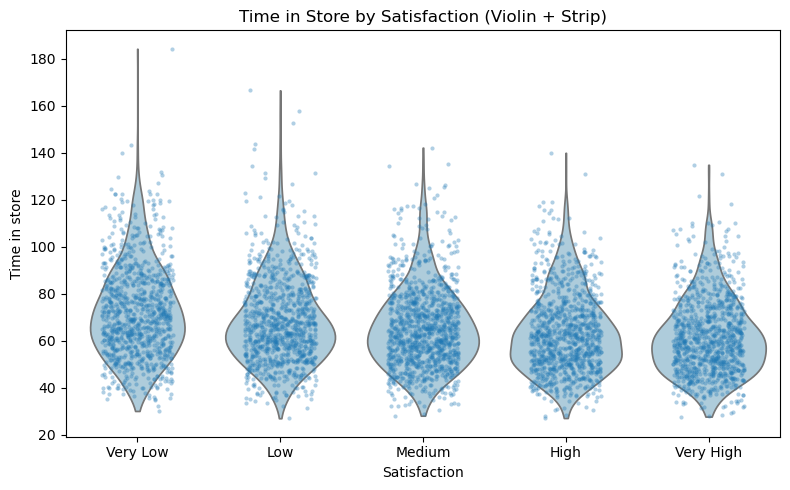

In [376]:
#Violin and Strip graph comparing time in store and satisfaction (Figure 5)
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df, x="satisfaction", y="average_time_in_store",
    inner=None, cut=0, color="#a6cee3"
)
sns.stripplot(
    data=df, x="satisfaction", y="average_time_in_store",
    color="#1f78b4", alpha=0.35, jitter=0.25, size=3 #Copilot generated
)
plt.title("Time in Store by Satisfaction (Violin + Strip)")
plt.xlabel("Satisfaction")
plt.ylabel("Time in store")
plt.tight_layout()
plt.show()

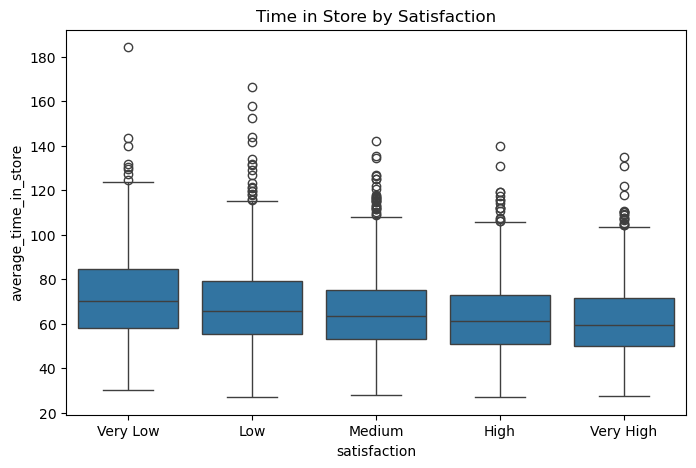

In [377]:
#Boxplot comparing time in store and satisfaction (Figure 6)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="satisfaction", y="average_time_in_store")
plt.title("Time in Store by Satisfaction")
plt.show()

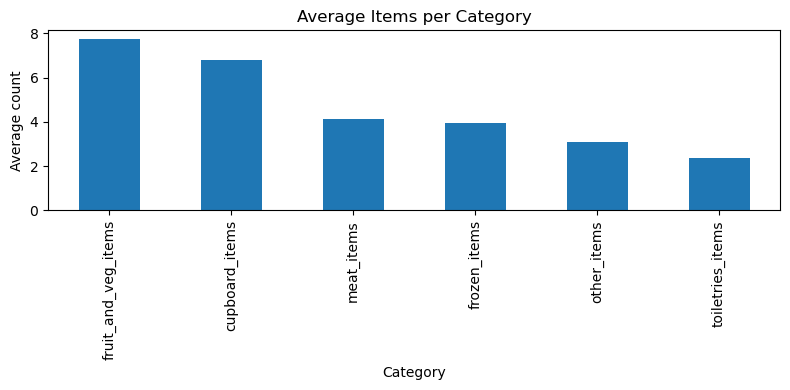

In [378]:
#Bar chart of the average number of items across shopping categories (Figure 7)
item_cols = [
    "fruit_and_veg_items",
    "meat_items",
    "cupboard_items",
    "frozen_items",
    "toiletries_items",
    "other_items"]

avg_items = df[item_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
avg_items.plot(kind="bar")
plt.title("Average Items per Category")
plt.xlabel("Category")
plt.ylabel("Average count")
plt.tight_layout()
plt.show()

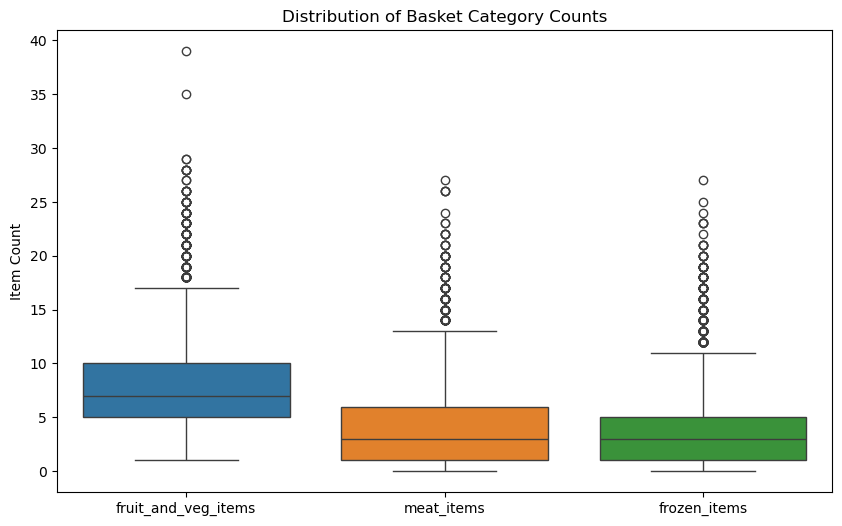

In [379]:
#Boxplot of basket composition (fruit/veg, meat, frozen food)(Figure 8)
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["fruit_and_veg_items", "meat_items", "frozen_items"]])
plt.title("Distribution of Basket Category Counts")
plt.ylabel("Item Count")
plt.show()

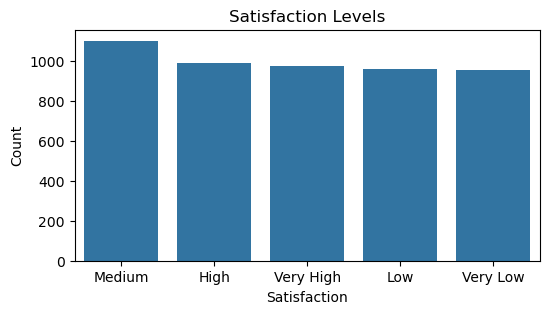

In [380]:
#Count plot of Satisfaction (Figure 9)
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="satisfaction", order=df["satisfaction"].value_counts().index)
plt.title("Satisfaction Levels")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

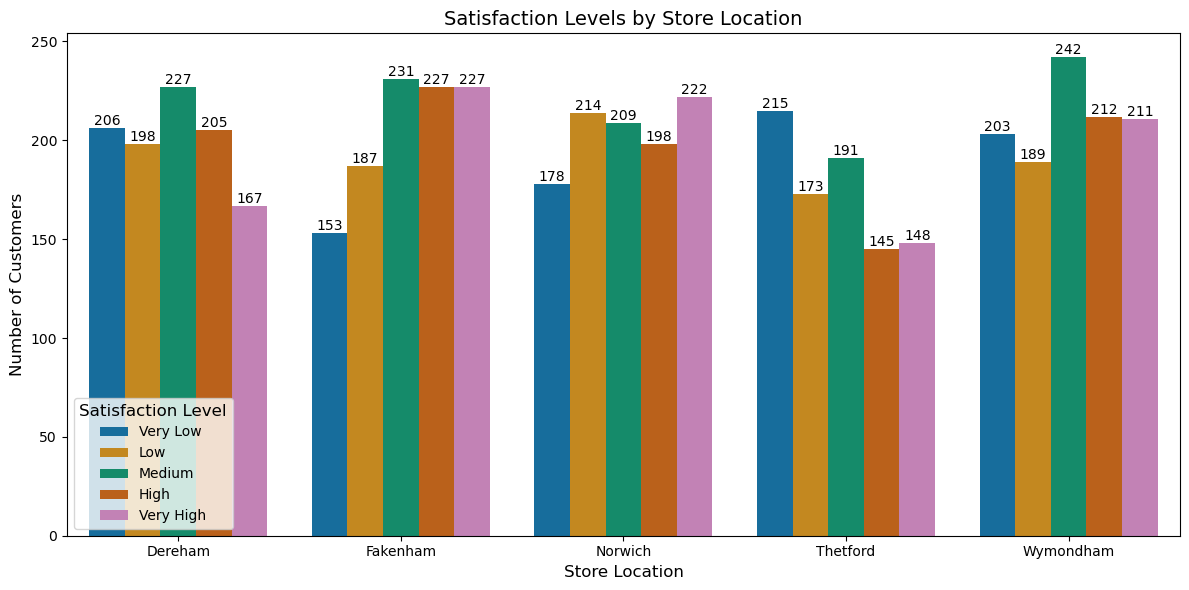

In [381]:
#Count plot of satisfaction by store location (Figure 10)
plt.figure(figsize=(12, 6))

#Plot with accessible spacing and colors
ax = sns.countplot(
    data=df, 
    x="store_location",
    hue="satisfaction",
    palette="colorblind")

plt.title("Satisfaction Levels by Store Location", fontsize=14)
plt.xlabel("Store Location", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

#Legend
plt.legend(title="Satisfaction Level", title_fontsize=12)

#Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

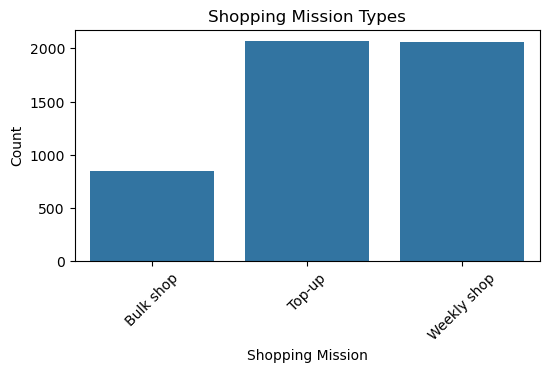

In [382]:
#Bar chart of shopping mission (Figure 11)
plt.figure(figsize=(6,3))
sns.countplot(data=df, x="typical_shopping_mission")
plt.xticks(rotation=45)
plt.title("Shopping Mission Types")
plt.xlabel("Shopping Mission")
plt.ylabel("Count")
plt.show()

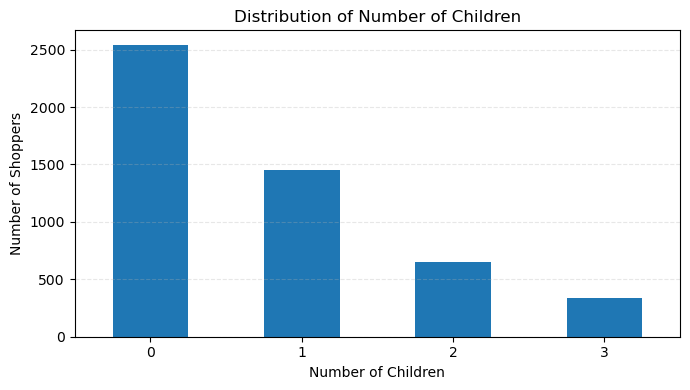

In [383]:
#Bar chart of number of children for every shopper (Figure 12)
child_counts = (df['children']
          .value_counts()
          .sort_index())

plt.figure(figsize=(7,4))
ax = child_counts.plot(kind='bar')

ax.set_title('Distribution of Number of Children')
ax.set_xlabel('Number of Children')
ax.set_ylabel('Number of Shoppers')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

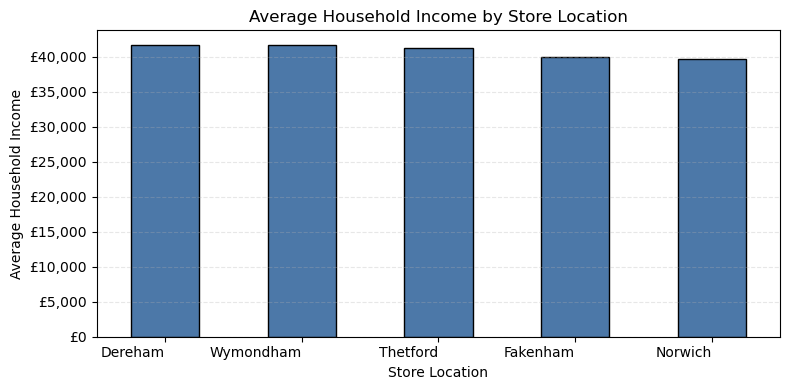

In [384]:
import matplotlib.ticker as mtick
#Bar chart of household income mean income by store location (Figure 13)
income_by_store = (
    df.groupby('store_location', observed=True)['household_income']
      .mean()
      .sort_values(ascending=False))

plt.figure(figsize=(8, 4))
ax = income_by_store.plot(kind='bar', color='#4C78A8', edgecolor='black')

ax.set_title('Average Household Income by Store Location')
ax.set_xlabel('Store Location')
ax.set_ylabel('Average Household Income')
plt.xticks(rotation=0, ha='right')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))

ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [385]:
income_by_store #Average household income by store location

store_location
Dereham      41696.124626
Wymondham    41661.956126
Thetford     41268.514048
Fakenham     39941.384390
Norwich      39636.589373
Name: household_income, dtype: float64

## Learning Task 
Predict customer’s satisfaction score based on their demographics and shopping behaviour.

- Task type: Regression
- Target column: satisfaction

In [386]:
#Counts of values in satisfaction column from different DataFrames
print(df['satisfaction'].value_counts(dropna=False))
print(supermarket['satisfaction'].value_counts(dropna=False)) #Original df

satisfaction
Medium       1100
High          987
Very High     975
Low           961
Very Low      955
Name: count, dtype: int64
satisfaction
Medium       1105
High          991
Very High     981
Low           966
Very Low      957
Name: count, dtype: int64


In [387]:
# Mapping
satisfaction_map = {
    'Very Low': 1,
    'Low': 2,
    'Medium': 3,
    'High': 4,
    'Very High': 5}

# Apply mapping to satisfaction column (assuming it exists)
if 'satisfaction' in df.columns:
    df['satisfaction_score'] = df['satisfaction'].map(satisfaction_map)

# Build total basket size
item_col = [
    'fruit_and_veg_items', 'meat_items', 'cupboard_items',
    'frozen_items', 'toiletries_items', 'other_items']

df['total_items'] = df[item_col].sum(axis=1)

predictors_num = [
    'age','typical_queue_wait_time',
    'percent_self_service_checkout_uses',
    'total_items',
    'distance_to_store',
    'household_income',
    'average_time_in_store']

predictors_cat = ['typical_shopping_mission']
df.shape

(4978, 23)

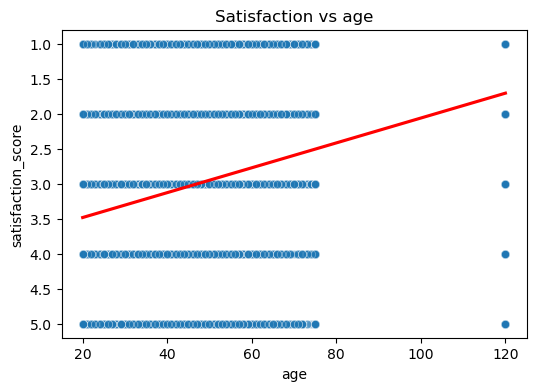

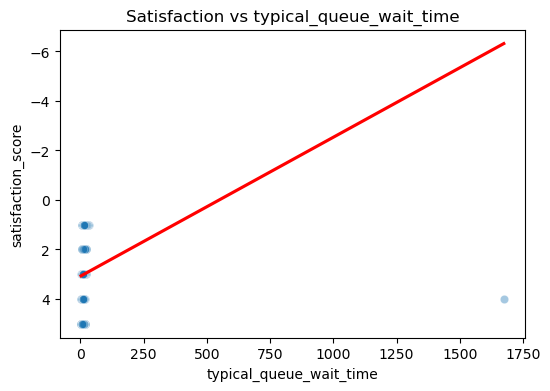

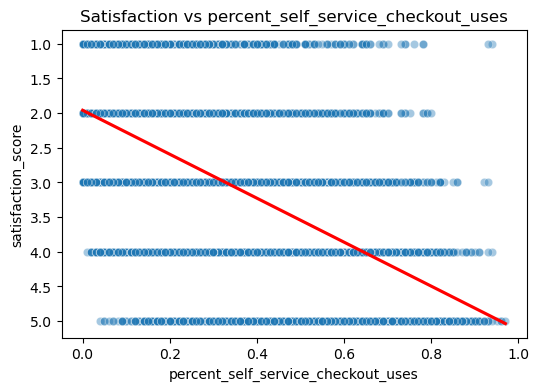

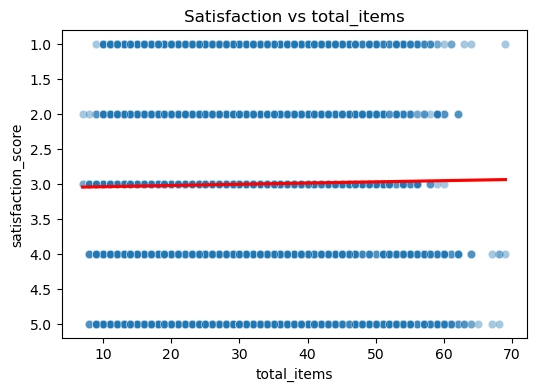

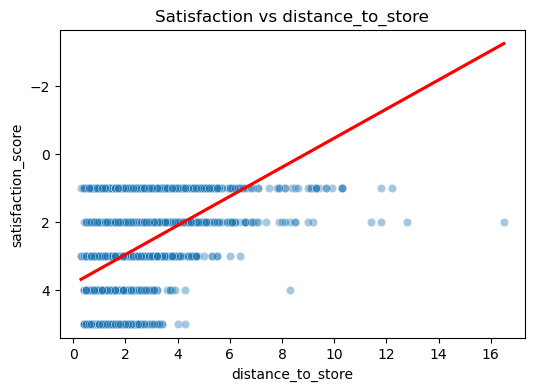

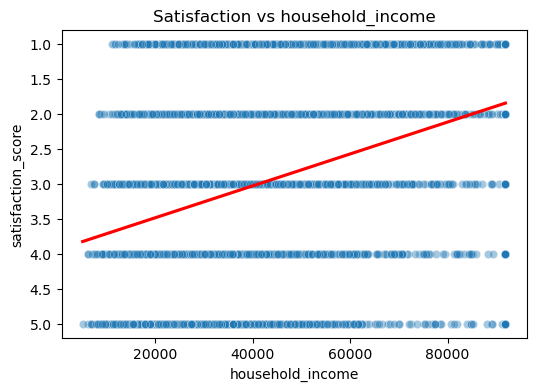

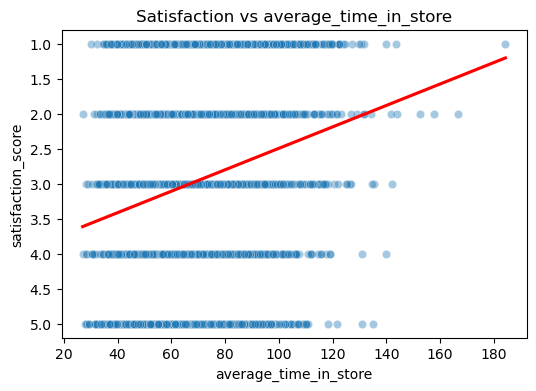

In [388]:
#Scatterplot for column in predictors_num (Figure 14)
for col in predictors_num:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y='satisfaction_score', alpha=0.4)
    sns.regplot(data=df, x=col, y='satisfaction_score', scatter=False, color='red', ci=None)
    plt.title(f"Satisfaction vs {col}")
    plt.show()

In [389]:
#Keyword dictionary and themes in very low to low satisfaction comments
complaint_keywords = {
    "Navigation": ["find", "confusing", "layout", "aisles", "navigate", "hard"],
    "Staff": ["staff", "help", "service", "unhelpful", "rude", "uninterested"],
    "Checkout": ["queue", "approval", "card", "checkout", "till", "wait"],
    "Stock": ["stock", "out", "missing", "expiry", "availability"],
    "Cleanliness": ["messy", "dirty", "tired", "spillages", "clean"],
    "Parking": ["parking", "car park", "space", "cramped", "difficult to park", "traffic"],
    "Pricing": ["price", "expensive", "overpriced", "value", "deal", "offer", "pricing", "high"]}

lowsat_df = df[df["satisfaction"].isin(["Very Low", "Low"])].copy()
def get_themes(comment):
    themes = []
    text = str(comment).lower()
    for theme, words in complaint_keywords.items():
        if any(w in text for w in words):
            themes.append(theme)
    return themes
lowsat_df["themes"] = lowsat_df["Customer_Comment"].apply(get_themes)

from collections import Counter

all_themes = [t for sublist in lowsat_df["themes"] for t in sublist]
Counter(all_themes) #tallied frequencies with counter

Counter({'Navigation': 510,
         'Checkout': 470,
         'Pricing': 469,
         'Stock': 419,
         'Staff': 340,
         'Parking': 193,
         'Cleanliness': 189})